 <span style="font-size: 25pt; font-weight: bold; color: #f17e1f;">**ANÁLISIS DE ESTADO Y DISTRIBUCIÓN DE ESTACIONES BIKI EN VALLADOLID** </span>

**Bloque 1.** Análisis de estado y distribución de las estaciones 

In [1]:
#Estaciones críticas: por saturación o vaciamiento 
#Calcular % de ocupación de cada estación (Numero de bicis / Total)
#análisis geográfico de capacidad. agrupación por zonas y averiguar déficit de anclajes



In [2]:
import io
import pandas as pd

#Datos consolidados del archivo de estaciones: 
csv_estaciones = """REFERENCIA;LUGAR;NÚMERO BICICLETAS;ESPACIOS LIBRES;TOTAL 
710;Calle Santiago Alba;7;8;15
705;Calle Ignacio Serrano ;9;9;18
701;CDO Covaresa;12;9;21
706;Calle Antonio Machado ;6;13;19
704;Calle Alcaparra;10;5;15
703;Calle José Velicia;4;11;15
702;Calle Atenas;10;4;14
708;Calle Villafrades de Campos;4;13;17
707;Agencia de Innovación ;7;12;19
709;Calle Ribera del Carrión ;9;6;15
504;Calle Bronce;6;5;11
601;Paseo de Zorrilla, 328;8;14;22
509;Barrio Arcas Reales;10;1;11
505;Calle Plata;7;4;11
1004;Calle Real (La Cistérniga);3;8;11
1003;Polígono San Cristóbal (La Cistérniga);8;3;11
508;Calle Cobalto;6;4;12
507;Calle Cromo;4;7;11
506;Calle Aluminio;4;7;11
510;Hospital Universitario Río Ortega HURH;14;13;27
501;Carretera de Segovia - UEMC;8;12;20
608;Calle Doctor Moreno;5;14;19
503;Calle Daniel del Olmo González;7;4;11
607;Calle Joaquín María Jalón;8;11;19
402;Calle Arca Real ;12;6;18
408;Calle Embajadores;7;11;18
407;Calle General Shelly;13;8;21
406;Paseo de Juan Carlos I;14;8;22
403;Paseo Arco de Ladrillo ;8;11;19
606;Calle Vives;5;8;13
603;Paseo de Zorrilla, 132;6;13;19
602;Casa de la India;13;10;23
609;Plaza de Toros;12;10;22
405;Plaza Gutiérrez Semprún ;5;10;15
301;Centro Cívico Zona Este;5;10;12
004;Plaza Circular;13;13;26
304;Calle Cigüeña ;3;8;11
303;Calle Golondrina;8;11;19
305;Calle del Cometa;4;17;21
306;Centro Cívico Pilarica;3;7;10
210;Plaza Vadillos;10;16;26
209;Paseo del Cauce;7;10;17
208;Facultad de Ciencias Económicas;14;4;18
202;Campus Miguel Delibes - CMD ;16;7;23
207;Avenida de Santander, 16;3;8;11
201;Centro Cívico Esgueva;8;13;21
013;Casa del Estudiante -  Hospital Clínico (HCUV);15;8;23
203;Plaza Ribera de Castilla ;7;11;18
204;Colegio Entre Ríos;8;13;21
206;Calle Portillo de Balboa, 1;5;13;18
010;Calle Cadenas de San Gregorio ;11;4;15
011;Facultad de Medicina;22;1;23
019;Calle de las Angustias;7;7;14
015;Plaza Libertad;5;20;25
001;Plaza Fuente Dorada;15;12;27
007;Plaza del Poniente;7;35;42
020;Calle María de Molina;11;12;23
009;Plaza de Zorrilla;6;21;27
002;Plaza Madrid;10;15;25
016;Plaza Caño Argales;17;10;27
401;Avenida de Segovia;15;12;27
404;Calle de Andalucía;2;11;13
012;Teatro Cervantes;12;14;26
006;Plaza de Santa Cruz;2;13;15
018;Calle Duque de la Victoria;7;12;19
014;Plaza San Miguel ;13;6;19
005;Plaza Trinidad;9;18;27
205;Hospital - Rondilla;9;9;18
102;Calle del Abedul ;8;7;15
101;Fuente el Sol ;8;7;15
103;Calle Júpiter;6;9;15
910;Calle de las Mieses;7;5;12
902;Recinto Feria de Valladolid;12;7;19
911;Calle Joaquín Velasco Martín, 1;3;14;17
901;Plaza del Milenio ;13;4;17
008;Paseo de Filipinos;17;9;26
605;Polideportivo Ponce de León ;21;2;23
801;Centro Cívico Casa Cuna;15;7;22
805;Calle Federico Landrove Moiño;7;8;15
803;Calle Profesor Adolfo Miaja de la Muela;15;3;18
804;Calle José Garrote Tebar;10;9;19
802;Plaza Marcos Fernández;7;15;22
807;Calle Hernando de Acuña;10;9;19
806;Calle de Manuel Azaña;5;14;19
808;Calle de Manuel Silvela;9;9;18
810;Piscina Municipal de Parquesol ;8;11;19
903;Plaza de Juan Pablo II;11;8;19
909;Calle del Monasterio de Santo Domingo de Silos;9;7;16
905;Centro Municipal José Luis Mosquera;9;8;17
906;Calle del Arado ;7;9;16
907;Calle de Rigoberto Cortejoso;3;16;19
104;Michelin ;7;4;11
1005;Centro Cívico (Santovenia);3;8;11
1006;Calle Fuentona (Santovenia);6;5;11
1001;Barrio La Overuela;8;3;11
302;Plaza Mayo ;8;3;11"""

#Limpiar espacios en blanco del nombre de las columnas
df_est = pd.read_csv(io.StringIO(csv_estaciones), sep=';')
df_est.columns = df_est.columns.str.strip()

#Mostrar datos:
print("Datos cargados y procesados con éxito")
print("\nLas cinco estaciones más saturadas:")
df_est['%Ocupacion'] = (df_est['NÚMERO BICICLETAS'] / df_est['TOTAL'] * 100).round(2)

print(df_est.sort_values(by='%Ocupacion', ascending=False).head(5)[['LUGAR','%Ocupacion']])

print("\nLas cinco estaciones más vacías:")
print(df_est.sort_values(by='%Ocupacion', ascending=True).head(5)[['LUGAR','%Ocupacion']])

Datos cargados y procesados con éxito

Las cinco estaciones más saturadas:
                                      LUGAR  %Ocupacion
51                     Facultad de Medicina       95.65
76             Polideportivo Ponce de León        91.30
12                      Barrio Arcas Reales       90.91
79  Calle Profesor Adolfo Miaja de la Muela       83.33
42          Facultad de Ciencias Económicas       77.78

Las cinco estaciones más vacías:
                              LUGAR  %Ocupacion
63              Plaza de Santa Cruz       13.33
61               Calle de Andalucía       15.38
90     Calle de Rigoberto Cortejoso       15.79
55               Plaza del Poniente       16.67
73  Calle Joaquín Velasco Martín, 1       17.65


Análisis de las métricas obtenidas: 
- La Facultad de medicina es la estación con más saturación de la red, con un 95.65% de ocupacion. 
- Le siguen de cerca Ponce de León y Arcas Reales, operando por encima del 90 por ciento. 
- En contraste, la Plaza de Santa Cruz y calle Andalucía registran el menor porcentaje, con un 13.3 y un 15.3 por ciento de su capacidad ocupada. 

In [3]:
#Analizar déficit de anclajes por zonas (agrupaciones geográficas)
#Qué comportamientos muestra cada territorio o barrio
#Utilizar la REFERENCIA numérica para agrupar por zonas (ejemplo: aquellos que empiezan por 5 pertenecen al Polígono de San Cristóbal)

In [4]:
# 1. Extraer zonas mediante los dos primeros dígitos de la columna REFERENCIA (asegurando limpieza)
df_est['Zona'] = df_est['REFERENCIA'].astype(str).str.strip().str[:4]

# 2. Agrupar por zonas usando los nombres EXACTOS de las columnas del CSV
analizar_zonas = df_est.groupby('Zona').agg({
    'TOTAL': 'sum',               
    'NÚMERO BICICLETAS': 'sum',   
    'ESPACIOS LIBRES': 'sum'       
}).reset_index()

# 3. Calcular porcentajes de ocupación con los nombres de columnas corregidos
analizar_zonas['%Ocupacion'] = ((analizar_zonas['NÚMERO BICICLETAS'] / analizar_zonas['TOTAL']) * 100).round(2)

# 4. Resultados: de MENOR a MAYOR saturación (ascending=True)
print("Análisis geográfico de capacidad por zonas (de menor a mayor):")
# Cambiado ascending a True para cumplir con tu comentario de "menor a mayor"
resultados = analizar_zonas.sort_values(by='%Ocupacion', ascending=True)[['Zona', '%Ocupacion']]
print(resultados)

Análisis geográfico de capacidad por zonas (de menor a mayor):
   Zona  %Ocupacion
56    6       13.33
41  404       15.38
92  907       15.79
65    7       16.67
95  911       17.65
..  ...         ...
28  208       77.78
79  803       83.33
54  509       90.91
60  605       91.30
11   11       95.65

[96 rows x 2 columns]


In [5]:
import pandas as pd
import plotly.express as px

# 1. Ordenar de menor a mayor ocupación
grafico_zonas = analizar_zonas.sort_values(by='%Ocupacion', ascending=True)

# 2. Extraer los extremos (5 con más déficit y 5 más saturadas)
zonas_con_deficit = grafico_zonas.head(5)
zonas_mas_saturadas = grafico_zonas.tail(5)

# 3. Combinar ambos bloques en un único DataFrame filtrado (10 zonas en total)
zonas_filtradas = pd.concat([zonas_con_deficit, zonas_mas_saturadas])

# 4. Crear el gráfico de barras horizontales interactivo 
fig = px.bar(
    zonas_filtradas,
    x='%Ocupacion',
    y='Zona',
    orientation='h',  # Barras horizontales
    title="<b>Zonas Críticas de BIKI Valladolid (Top 5 Menor vs. Top 5 Mayor Ocupación)</b><br><sup>Tonos claros: Mayor margen de recepción | Tonos oscuros: Al límite de capacidad</sup>",
    labels={'%Ocupacion': 'Porcentaje de Ocupación Real (%)', 'Zona': 'Zonas / Distritos'},
    color='%Ocupacion',  # El color de la barra dependerá del porcentaje de ocupación
    color_continuous_scale=px.colors.sequential.Oranges,  # Mantiene tu escala de naranjas armónica
    text_auto='.1f'  # Muestra automáticamente el porcentaje dentro/al lado de la barra
)

# 5. Personalizar diseño 
fig.update_layout(
    title_font_size=16,
    xaxis_title_font_size=13,
    yaxis_title_font_size=13,
    xaxis=dict(range=[0, 110]),  # Fijar el rango del eje X para que no se corten los textos
    coloraxis_showscale=False,  # Ocultamos la barra de escala de color lateral para limpiar el diseño
    yaxis=dict(type='category'),  # Forzar a que las zonas se traten como categorías fijas
    margin=dict(l=50, r=50, t=80, b=50),
    template="plotly_white"  # Fondo blanco limpio que combina con el 'whitegrid' de seaborn
)

# Posicionar el texto del porcentaje fuera de la barra 
fig.update_traces(textposition='outside', cliponaxis=False)

# 6. Mostrar el gráfico interactivo en el Jupyter Notebook
fig.show()


**Bloque 2.** Análisis de tendencia temporal y crecimiento 

In [6]:
#Análisis de tendencias temporales y crecimiento: 
#Objetivo: Analizar la evolución de usuarios registrados mensualmente mediante el cálculo de variaciones
#interanuales, y mapear el comportamiento histórico real de BIKI. 

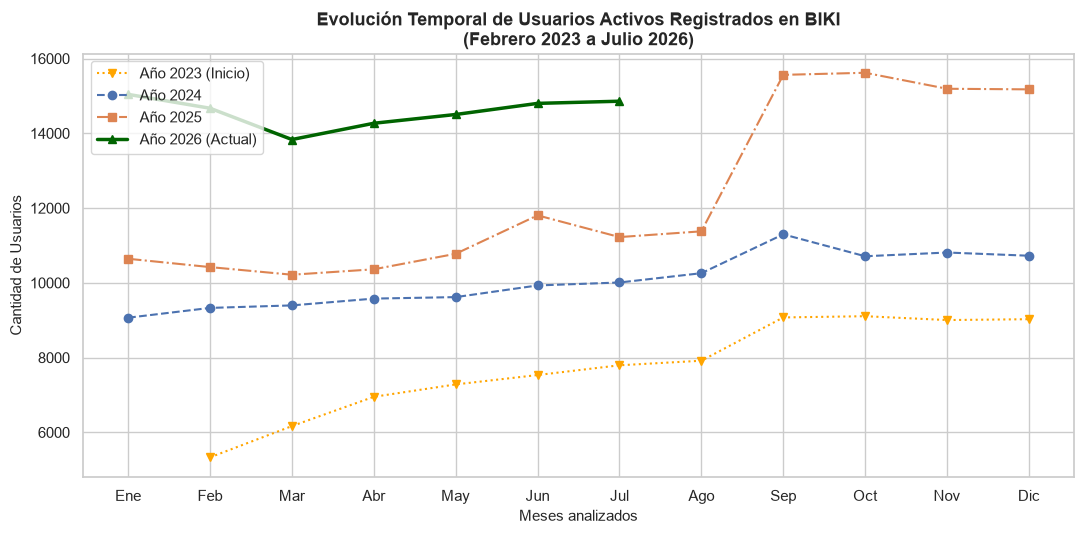

Evolución de usuarios de BIKI (Febrero 2023 a Julio 2026)


In [7]:
from io import BytesIO
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo de la gráfica
sns.set_theme(style="whitegrid")

# Histórico de usuarios registrados a final de cada mes (Extraído de tus fuentes)
# Nota: Enero 2023 se marca como None ya que el servicio comenzó en febrero de 2023.
meses = [
    "Ene",
    "Feb",
    "Mar",
    "Abr",
    "May",
    "Jun",
    "Jul",
    "Ago",
    "Sep",
    "Oct",
    "Nov",
    "Dic",
]
usuarios_2023 = [
    None,
    5331,
    6167,
    6951,
    7282,
    7533,
    7794,
    7916,
    9074,
    9107,
    9004,
    9027,
]
usuarios_2024 = [
    9067,
    9329,
    9396,
    9578,
    9618,
    9930,
    10009,
    10258,
    11297,
    10711,
    10811,
    10725,
]
usuarios_2025 = [
    10644,
    10421,
    10217,
    10362,
    10777,
    11805,
    11224,
    11378,
    15564,
    15620,
    15192,
    15176,
]
usuarios_2026 = [
    15042,
    14671,
    13834,
    14269,
    14504,
    14801,
    14859,
    None,
    None,
    None,
    None,
    None,
]

# Graficar serie de tiempo lineal comparativa
plt.figure(figsize=(11, 5.5))

# Añadimos la línea del año de inauguración (2023)
plt.plot(
    meses,
    usuarios_2023,
    marker="v",
    linestyle=":",
    color="orange",
    label="Año 2023 (Inicio)",
)
plt.plot(meses, usuarios_2024, marker="o", linestyle="--", label="Año 2024")
plt.plot(meses, usuarios_2025, marker="s", linestyle="-.", label="Año 2025")
plt.plot(
    meses,
    usuarios_2026,
    marker="^",
    linestyle="-",
    linewidth=2.5,
    color="darkgreen",
    label="Año 2026 (Actual)",
)

# Títulos y formato
plt.title(
    "Evolución Temporal de Usuarios Activos Registrados en BIKI\n(Febrero 2023 a Julio 2026)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Meses analizados", fontsize=11)
plt.ylabel("Cantidad de Usuarios", fontsize=11)
plt.legend(loc="upper left")
plt.tight_layout()

# Uso de BytesIO tal como lo estructuraste para manejo en memoria
buf = BytesIO()
plt.savefig(buf, format="png", dpi=300)
buf.seek(0)

# Mostrar el resultado en pantalla en VS Code
plt.show()

print("Evolución de usuarios de BIKI (Febrero 2023 a Julio 2026)")

Este gráfico nos aporta varios puntos de partida: observamos cómo el servicio arranca en febrero de 2023 con 5331 usuarios, escalando de manera rápida en un 45%, cerrando el año superando los nueve mil usuarios. 
Observamos además una serie de picos que aparecen especialmente marcados, como son los que se reflejan en el mes de Septiembre y Octubre en cualquiera de los años, coincidiendo con el inicio del curso universitario en Valladolid y la vuelta al colegio. 

**Bloque 3.** Preferencias de uso: bicicletas mecánicas vs eléctricas 

In [8]:
#Histórico de viajes: calcula porcentaje del mercado dominado por cada vehículo 
#Objtivo: comprobar si hay mayor uso de bicicleta convencional o se opta por aquellas con asistencia al pedaleo 

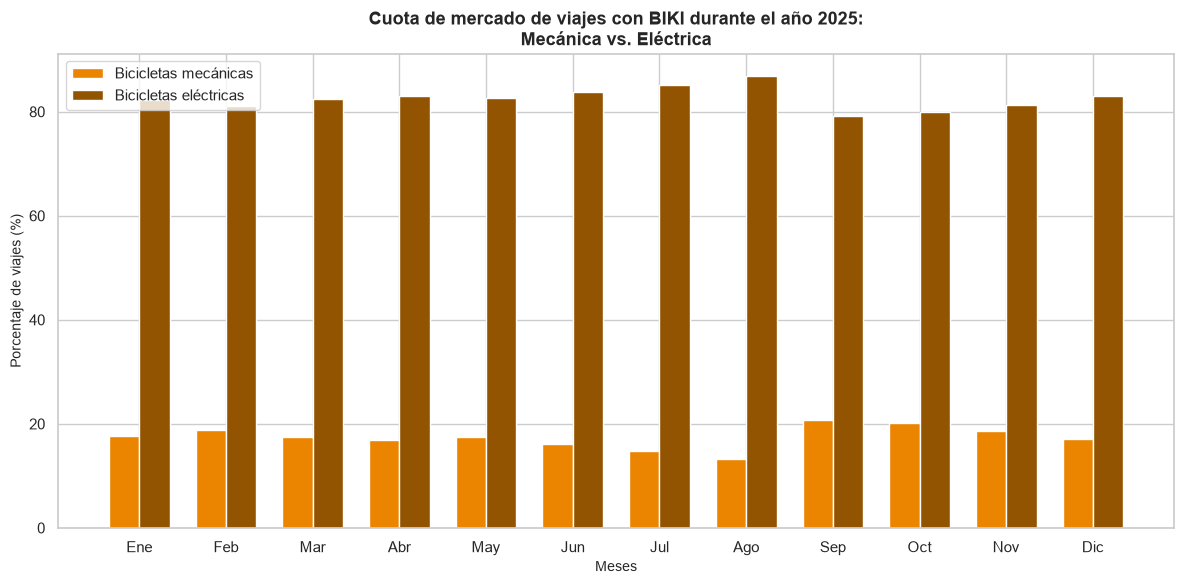

Media anual de uso de bicicletas ELÉCTRICAS en 2025: 82.56
Media anual de uso de bicicletas MECÁNICAS en 2025: 17.44


In [9]:
#En este bloque tomamos como referencia el año 2025:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#Configuración
sns.set_theme(style="whitegrid")

#Datos completos y consolidados del año 2025:
meses_b3 = [
    "Ene",
    "Feb",
    "Mar",
    "Abr",
    "May",
    "Jun",
    "Jul",
    "Ago",
    "Sep",
    "Oct",
    "Nov",
    "Dic",
]
mecanicas_2025 = [
    7372,
    8810,
    9002,
    9234,
    11354,
    11189,
    9695,
    7988,
    21318,
    20454,
    13925,
    10867,
]
electricas_2025 = [
    34196,
    37931,
    42362,
    45268,
    53704,
    57951,
    55487,
    52701,
    81102,
    81112,
    60802,
    52981,
]

#Crear DF para facilitar los cálculos de la cuota de mercado
df_tipos = pd.DataFrame(
    {
        "Mes": meses_b3,
        "Mecánica": mecanicas_2025,
        "Eléctrica": electricas_2025,
        "Total": [m + e for m, e in zip(mecanicas_2025, electricas_2025)],
    }
)

#Calcular % de cuota de mercado
df_tipos["%Mecanica"] = (df_tipos["Mecánica"] / df_tipos["Total"]) * 100
df_tipos["%Electrica"] = (df_tipos["Eléctrica"] / df_tipos["Total"]) * 100

#Gráfico con barras separadas para que ambas series sean visibles
x = range(len(df_tipos))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(
    [i - width / 2 for i in x],
    df_tipos["%Mecanica"],
    width=width,
    label="Bicicletas mecánicas",
    color="#eb8500",
)
plt.bar(
    [i + width / 2 for i in x],
    df_tipos["%Electrica"],
    width=width,
    label="Bicicletas eléctricas",
    color="#935402",
)

plt.xticks(list(x), df_tipos["Mes"])
plt.title(
    "Cuota de mercado de viajes con BIKI durante el año 2025:\nMecánica vs. Eléctrica",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Meses", fontsize=10)
plt.ylabel("Porcentaje de viajes (%)", fontsize=10)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

#Mostrar medias anuales
print(f"Media anual de uso de bicicletas ELÉCTRICAS en 2025: {df_tipos['%Electrica'].mean():.2f}")
print(f"Media anual de uso de bicicletas MECÁNICAS en 2025: {df_tipos['%Mecanica'].mean():.2f}")

Algunas conclusiones: 
- *Dominio de la bicicleta eléctrica*: acapara más del 80 por ciento del total de viajes realizados al mes. 
- *Efecto cuesta*: teniendo en cuenta la topografía presente en ciertas partes de la ciudad de Valladolid (como por ejemplo el barrio de Parquesol) y la comodidad de la bicicleta eléctrica explican su dominio, quedando la bicicleta convencional relegada a un segundo plano en lo que respecta a cuota de mercado. 

**Bloque 4.** Análisis demográfico, perfil del usuario

In [10]:
#Objetivo: analizar la composicion de la comunidad de usuarios de BIKI en base al histórico disponible 
#Evaluar si la brecha de género se mantiene estable o se ha reducido
#En este caso tomamos el año 2025 como referencia a año completo y 2026 con los meses de enero a julio

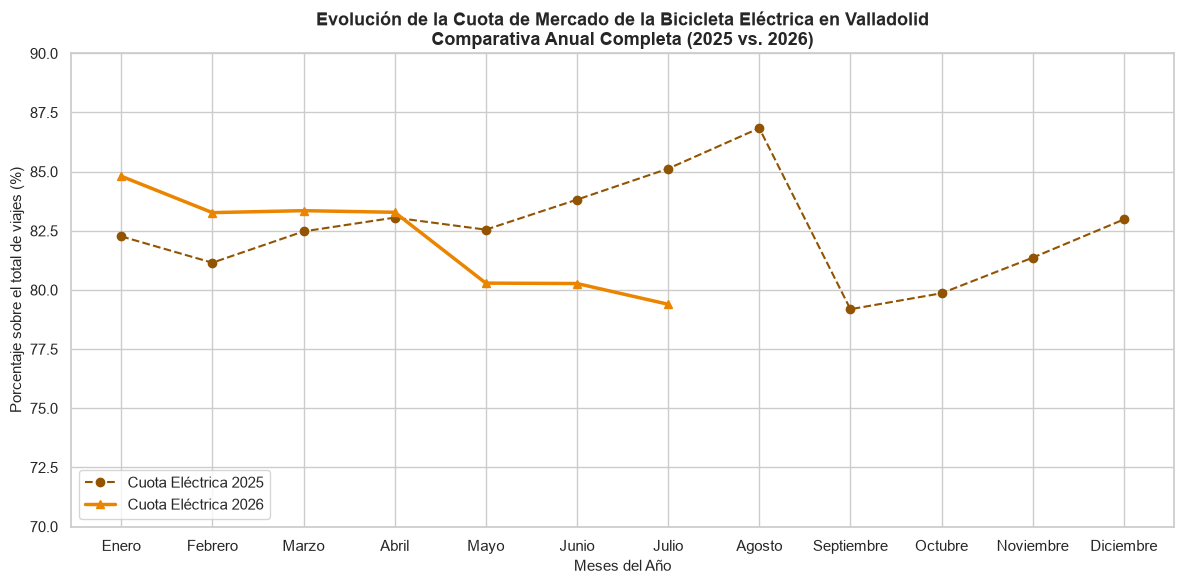

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

#Definir con los 12 meses (para el 2026: los meses que todavía no han tenido lugar se completan con "None")
meses_b3 = ["Enero","Febrero","Marzo","Abril","Mayo","Junio","Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"]

#Datos del año 2025:
mec_2025 = [7372, 8810, 9002, 9234, 11354, 11189, 9695, 7988, 21318, 20454, 13925, 10867]
elec_2025 = [34196, 37931, 42362, 45268, 53704, 57951, 55487, 52701, 81102, 81112, 60802, 52981]

#Datos del año 2026 (enero-julio)
mec_2026 = [7915, 8735, 12109, 12857, 16132, 16891, 15464, None, None, None, None, None]
elec_2026 = [44178, 43471, 60623, 64053, 65711, 68726, 59589, None, None, None, None, None]

#Creación del DataFrame con pandas: 
df_cuotas = pd.DataFrame({
    "Mes": meses_b3,
    "Mec_2025": mec_2025,
    "Elec_2025": elec_2025,
    "Mec_2026": mec_2026,
    "Elec_2026": elec_2026
})
#Cálculo de la cuota porcentual de la bicicleta eléctrica
df_cuotas["% Elec 2025"] = (df_cuotas["Elec_2025"] / (df_cuotas["Elec_2025"] + df_cuotas["Mec_2025"])) * 100
#Gestionar los valores None (NaN) correspondientes a los meses de agosto a diciembre del 2026
df_cuotas["% Elec 2026"] = (df_cuotas["Elec_2026"] / (df_cuotas["Elec_2026"] + df_cuotas["Mec_2026"])) * 100

# 4. Generación de la gráfica comparativa de líneas
plt.figure(figsize=(12, 6))
plt.plot(df_cuotas["Mes"], df_cuotas["% Elec 2025"], marker='o', linestyle='--', color="#935402", label='Cuota Eléctrica 2025')
plt.plot(df_cuotas["Mes"], df_cuotas["% Elec 2026"], marker='^', linestyle='-', linewidth=2.5, color="#eb8500", label='Cuota Eléctrica 2026')

plt.title('Evolución de la Cuota de Mercado de la Bicicleta Eléctrica en Valladolid\nComparativa Anual Completa (2025 vs. 2026)', fontsize=13, fontweight='bold')
plt.xlabel('Meses del Año', fontsize=11)
plt.ylabel('Porcentaje sobre el total de viajes (%)', fontsize=11)
plt.ylim(70, 90)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

**Conclusiones del modelo de tendencia (BIKI 2026)**

- **Crecimiento orgánico:**. Cuando comparamos el tramo de enero a julio de 2026 con los meses correspondientes al 2025, observamos que el año presente se sitúa por encima en número de viajes y usuarios. No es un pico que se dé en casos puntuales, sino que estamos ante una tendencia ascendente estructural. 
- **Comportamiento de la línea base del 2025:** si observamos la serie completa del año anterior, se aprecia un descenso de unos 60.000 viajes, que coinciden con las vacaciones del mes de Agosto. Septiembre, en contraste, muestra un repunte que lleva a alcanzar el pico más alto del año, llegando a los 102.420 usos mensuales. 
- **Proyección del mes de Septiemnbre:** observamos que los primeros seis meses del 2026 operan con un volumen superior al del año anterior. Teniendo en cuenta factores como la llegada de estudiantes a los campus universitarios o la reactivación laboral, la hipçotesis es que septiembre de 2026 puede mantener la tendencia alcista superando con creces las cifras del 2025. 
- **Preferencias:** se mantienen estables, el crecimiento en el uso no altera los hábitos de los usuarios, pues la bicicleta eléctrica retiene una cuota idéntica (en el 2025 representó el 83.18%) y el 82.35% del período analizado del año 2026. 

**Bloque 5.** Impacto de las tarifas y tipo de usuarios (Ocasional vs Bonos)

In [12]:
#simulación de tarifas. para calcular en qué punto (viajes al mes) resulta rentable pasar
#de una tarifa de usuario "Ocasional" a una tarifa plana (bono)

#Umbral de rentabilidad de tarifas 

Modalidad por suscripción (uso ocasional)
- Mensual: Mecánica (4€ al mes), eléctrica (6€ al mes)
- Anual: Mecánica (10€ al año), eléctrica (40€ al año)

Modalidad por bono o tarifa plana:
- Mensual: Mecánica (16€ mes), eléctrica (28€ mes)
- Anual: mecánica (130€ año), eléctrica (256€ año)

Trayectos: máximo 30 minutos cada uno 
Exceso de tiempo: recargo por cada 30 minutos adicionales (mecánica: 0,25€, eléctrica: 0,45€)

Usuarios globales: 15200
Usuarios activos mensuales: entre 10000 y 11500
incremento del servicio de enero a julio de 2026: 4250 usuarios nuevos

Análisis de rentabilidad de tarifas BIKI
La bicicleta Mecánica: su bono se amortiza a partir del viaje 48.
Es rentable contratar bono a partir de los 48 viajes al mes.
La bicicleta Eléctrica: su bono se amortiza a partir del viaje 29.
Es rentable contratar bono a partir de los 30 viajes al mes.


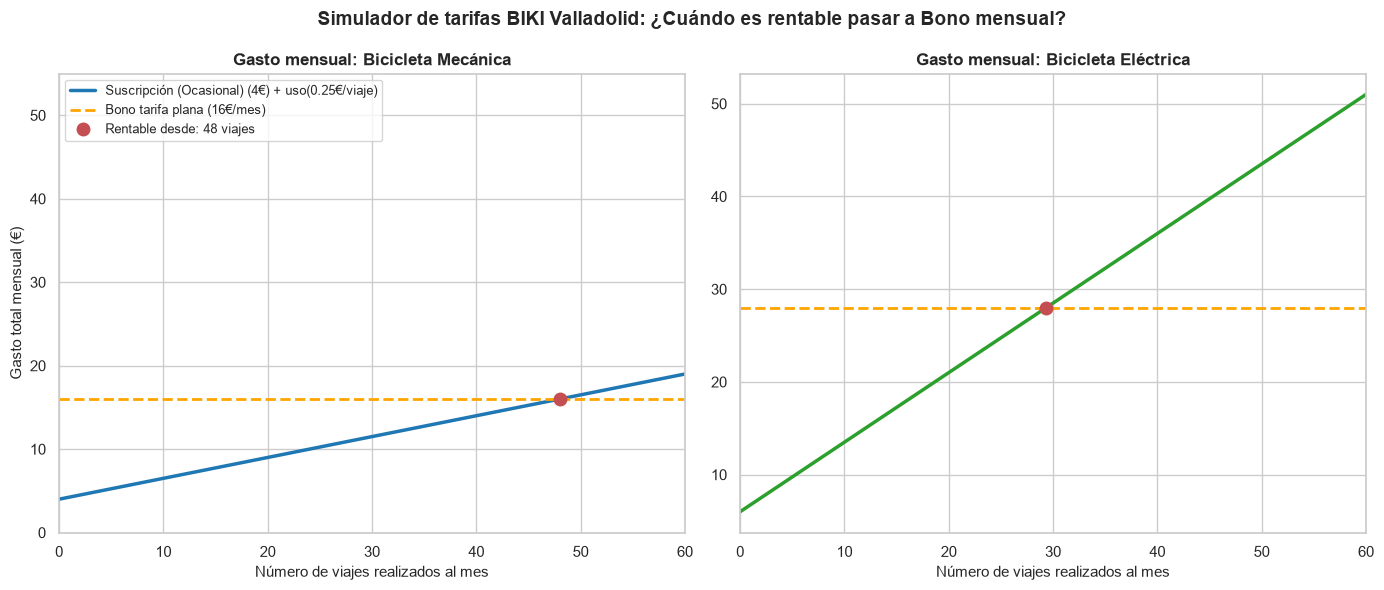

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# Definir parámetros de sistema BIKI

tarifas = {
    "Mecánica": {
        "suscripcion_mes": 4.0,
        "bono_mes": 16.0,
        "coste_viaje": 0.25,
        "color": "#1f77b4",
    },
    "Eléctrica": {
        "suscripcion_mes": 6.0,
        "bono_mes": 28.0,
        "coste_viaje": 0.75,
        "color": "#2ca02c",
    },
}

# Rango a simular en un mes: de 0 a 60 viajes
viajes = np.arange(0, 61)

# Crear figura en dos partes para cada tipo de bicicleta
fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True)
axes = {"Mecánica": ax1, "Eléctrica": ax2}
print("Análisis de rentabilidad de tarifas BIKI")

for tipo, datos in tarifas.items():
    ax = axes[tipo]

    # Coste total mensual
    coste_ocasional = datos["suscripcion_mes"] + (viajes * datos["coste_viaje"])
    coste_bono = np.full_like(viajes, datos["bono_mes"], dtype=float)

    # Punto de equilibrio. Fórmula: (Coste Bono - Coste Suscripción) / Coste por viaje
    punto_equilibrio = (datos["bono_mes"] - datos["suscripcion_mes"]) / datos["coste_viaje"]

    # Graficar curva de costes
    ax.plot(
        viajes,
        coste_ocasional,
        label=f"Suscripción (Ocasional) ({datos['suscripcion_mes']:.0f}€) + uso({datos['coste_viaje']:.2f}€/viaje)",
        color=datos["color"],
        linewidth=2.5,
    )

    ax.axhline(
        y=datos["bono_mes"],
        color="orange",
        linestyle="--",
        linewidth=2,
        label=f"Bono tarifa plana ({datos['bono_mes']:.0f}€/mes)",
    )

    # Marcar punto de cruce de la gráfica
    ax.plot(
        punto_equilibrio,
        datos["bono_mes"],
        "ro",
        markersize=9,
        label=f"Rentable desde: {np.ceil(punto_equilibrio):.0f} viajes",
    )

    # Personalizar gráfica
    ax.set_title(f"Gasto mensual: Bicicleta {tipo}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Número de viajes realizados al mes", fontsize=11)

    if tipo == "Mecánica":
        ax.set_ylabel("Gasto total mensual (€)", fontsize=11)
        ax.set_xlim(0, 60)
        ax.set_ylim(0, 55)
        ax.legend(loc="upper left", fontsize=9)

    print(f"La bicicleta {tipo}: su bono se amortiza a partir del viaje {punto_equilibrio:.0f}.")
    print(f"Es rentable contratar bono a partir de los {np.ceil(punto_equilibrio):.0f} viajes al mes.")

plt.suptitle(
    "Simulador de tarifas BIKI Valladolid: ¿Cuándo es rentable pasar a Bono mensual?",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout()

# Guardar gráfico en carpeta
plt.savefig("analisis_rentabilidad_tarifas.png", dpi=300)
plt.show()

**Bloque 6.** Análisis de perfil

In [14]:
#En este caso tomamos como ejemplo a un estudiante universitario (flujo: Campus Miguel Delibes)
#Puntos de origen comunes: 
    #Casa del Estudiante / Hospital Clínico (Referencia 013)
    #Plaza Madrid (con referencia 002)
    #Plaza Circular (004)
#Destino:
    #Campus Miguel Delibes (202)
    #Hospital Universitario Río Hortega / UEMC (501)

In [15]:
#Interpretar la referencia 501 (Correspondiente a UEMC)
#Objetivo: Incorporar los dos flujos universitarios de la ciudad 

perfil_ruta = {"Estudiante Universitario (UVa - Norte)": {
        "origen_lugar": "Plaza Madrid / Casa del Estudiante",
        "origen_coordenadas": [41.6483, -4.7235],
        "destino_lugar": "Campus Miguel Delibes (UVa - Ref 202)",
        "destino_coordenadas": [41.6631, -4.7058],
        "criterio": "Priorizar el eje del Paseo del Cauce. Entorno seguro y segregado.",
        "tipo_bici_recomendada": "Mecánica (Perfil llano, ideal para uso diario recurrente de estudiantes)."
    },
    "Estudiante UEMC / Personal Sanitario (Sureste)": {
        "origen_lugar": "Plaza Circular / Avenida de Segovia",
        "origen_coordenadas": [41.6491, -4.7172],
        "destino_lugar": "Hospital Río Hortega / Campus UEMC (Ref 501)",
        "destino_coordenadas": [41.6263, -4.7163],
        "criterio": "Conectar mediante el carril bici de Delicias hacia el eje de la Carretera de Segovia. Evitar nudos de tráfico de los polígonos industriales.",
        "tipo_bici_recomendada": "Eléctrica (Recomendada debido a la distancia periférica y los tiempos de traslado ajustados de trabajadores de turnos)."
    },
    "Trabajador Pendular (Parquesol - Oeste)": {
        "origen_lugar": "Plaza de Zorrilla (Centro)",
        "origen_coordenadas": [41.6496, -4.7314],
        "destino_lugar": "Calle Profesor Adolfo Miaja de la Muela (Parquesol - Ref 803)",
        "destino_coordenadas": [41.6425, -4.7611],
        "criterio": "Ruta directa salvando el fuerte desnivel del barrio.",
        "tipo_bici_recomendada": "Eléctrica obligatoria (para contrarrestar la rampa de subida a Parquesol)."
    }
}

#Imprimir catálogo de rutas óptimas 
print("Catálogo de rutas óptimas BIKI")
for perfil, datos in perfil_ruta.items():
    print(f"\n[Perfil]: {perfil}")
    print(f"  * Origen: {datos['origen_lugar']}")
    print(f"  * Destino: {datos['destino_lugar']}")
    print(f"  * Estrategia de trazado: {datos['criterio']}")
    print(f"  * Recomendación de flota: {datos['tipo_bici_recomendada']}")
    
    

Catálogo de rutas óptimas BIKI

[Perfil]: Estudiante Universitario (UVa - Norte)
  * Origen: Plaza Madrid / Casa del Estudiante
  * Destino: Campus Miguel Delibes (UVa - Ref 202)
  * Estrategia de trazado: Priorizar el eje del Paseo del Cauce. Entorno seguro y segregado.
  * Recomendación de flota: Mecánica (Perfil llano, ideal para uso diario recurrente de estudiantes).

[Perfil]: Estudiante UEMC / Personal Sanitario (Sureste)
  * Origen: Plaza Circular / Avenida de Segovia
  * Destino: Hospital Río Hortega / Campus UEMC (Ref 501)
  * Estrategia de trazado: Conectar mediante el carril bici de Delicias hacia el eje de la Carretera de Segovia. Evitar nudos de tráfico de los polígonos industriales.
  * Recomendación de flota: Eléctrica (Recomendada debido a la distancia periférica y los tiempos de traslado ajustados de trabajadores de turnos).

[Perfil]: Trabajador Pendular (Parquesol - Oeste)
  * Origen: Plaza de Zorrilla (Centro)
  * Destino: Calle Profesor Adolfo Miaja de la Muela (Pa

Justificación de movilidad: Eje Hospital Río Hortega / UEMC (501)

1. Dos modelos universitarios: Campus miguel Delibes, situado en el norte urbano, y UEMC, centro privado, en el límite sureste. Esta última se localiza en una zona de reciente desarrollo y alejada del centro, al igual que el Hospital, lo que implica mayor tiempo de desplazamiento. Aquí,la **bicicleta eléctrica** se posiciona como uno de los medios con mejor ventaja competitiva respecto al autobús urbano o el coche. 
2. Equilibrio estaciones con referencias 501 y 510: La estación situada junto al Hospital Río Hortega (510) tiene una capacidad de 27 anclajes, en contraste con la de UEMC (501), con un total de veinte. El planificador de BIKI previó un alto volumen de intercambio entre ambas, y eso lo convierte en punto clave para medir los flujos de entrada o salida de trabajadores del hospital por turnos. 

In [16]:
import pandas as pd
import plotly.express as px

# 1. Matriz de datos para perfiles de ruta
datos_rutas = {
    "Perfil de usuario": [
        "Estudiante UVA (Norte)",
        "Estudiante UEMC (Sureste)",
        "Trabajador pendular (Oeste)"
    ],
    "Trayecto": [
        "Plaza Madrid ➔ Campus Delibes (Ref 202)", 
        "Plaza Circular ➔ Hosp. Río Hortega (Ref 501)", 
        "Plaza Zorrilla ➔ Parquesol (Ref 803)"
    ],
    "Distancia (Km)": [2.4, 3.8, 3.1],
    "Dificultad Numérica": [1, 2, 3],  # Mapear el color degradado
    "Bici Recomendada": ["Mecánica", "Eléctrica", "Eléctrica"],
    "Dificultad Topográfica": ["Baja (Llano)", "Media (Falso Llano)", "Alta (Pendiente Fuerte)"]
}

df_bubble = pd.DataFrame(datos_rutas)

# 2. Generar gráfico de burbujas (plotly)
bubble_fig = px.scatter(
    df_bubble,
    x="Distancia (Km)",
    y="Dificultad Topográfica", 
    size="Distancia (Km)",       
    color="Dificultad Numérica", 
    color_continuous_scale=px.colors.sequential.Oranges,
    hover_name="Perfil de usuario",
    hover_data=["Trayecto", "Bici Recomendada"],
    title="<b>Matriz de Esfuerzo de Rutas BIKI por Perfil</b><br><sup>El tamaño de la burbuja indica la longitud; la intensidad del naranja, la dificultad del terreno</sup>",
    labels={
        "Distancia (Km)": "Distancia del Trayecto (Km)",
        "Dificultad Topográfica": "Complejidad del Terreno"
    }
)

# 3. Ajustar estilo y forzar rango en los ejes 
bubble_fig.update_layout(
    template="plotly_white",
    title_font_size=15,
    coloraxis_showscale=False,
    margin=dict(l=50, r=50, t=80, b=50),
    xaxis=dict(range=[2.0, 4.2]), 
    yaxis=dict(type='category')
)

# SOLUCIÓN: Cambiamos a 'diameter' y ajustamos el 'sizeref'
bubble_fig.update_traces(
    marker=dict(
        sizemode='diameter', 
        sizeref=0.08,        # Controla el escalado general de los tres diámetros
        sizemin=20           # Tamaño mínimo en píxeles 
    )
)

bubble_fig.show()





**Algunas conclusiones**

1. Eje universitario como motor de frecuencia:
- El estudiante de la UVA se encuentra en la esquina inferior izquierda de la matriz, representado en una burbuja de menor tamaño y un tono naranja muy suave. Presenta una complejidad topográfica baja (2,4 km) y una distancia corta (2.4 km)

- El eje comprendido por Plaza MAdrid - Campus Miguel Delibes es el mejor escenario para la bicicleta mecánica, pues es un trayecto que no presenta desniveles y los estudiantes pueden realizarlo de forma recurrente. Este punto puede relacionarse directamente con el anterior, en el cual se analizan las tarifas: un estudiante qie va y viene de casa amortiza el bono mensual de bicicleta convencional o mecánica con facilidad. 

2. Eje sanitario: flujo eléctrico 
- El estudiante de la UEMC está representado por la burbuja de mayor tamaño del gráfico y un tono naranja, con la ruta más larga (3.8 km) y dificultad media. 
- Con objeto de conectar Plaza Circular con el HURH y el campus de la UEMC, la bicicleta eléctrica pasa a ser la mejor opción, pues los horarios más rígidos y la mayor distancia requieren más velocidad. Aquí se refleja la razón de por qué la bicicleta eléctrica domina la cuota de mercado en estas estaciones, siendo éste eje una zona de alta prioridad de abastecimiento. 

3. Eje oeste: Parquesol. Flujo eléctrico de esfuerzo 
- El trabajador pendular está representado por la burbuja en color marrón oscuro, reflejando la mayor complejidad de terreno, con pendiente fuerte. 
- La distancia es de 3.1 kilómetros, pero las rampas de subida del barrio de Parquesol hacen que estre trayecto sea más difícil de practicar para el usuario de bicicleta convencional. Ello explica la saturación de espacios libres por la mañana (personas que bajan al centro, sin apenas esfuerzo). 

In [17]:
#Perfil estudiante o investigador: conexión de Facultad de Medicina (011) y 
#Facultad de Ciencias Económicas (208)
#Al no disponer de coordenadas usamos REFERENCIA: columna que refleja el perfil geográfico que agrupa
#estaciones por cercanía y distrito 

import pandas as pd
import plotly.express as px # type: ignore

#1. Definir distancia media estimada (km) desde cada punto de origen hasta cada destino universitario 

distancia_media = {
    "Zona Origen": ["00 (Centro)", "30 (Pajarillos/Este)", "40 (Delicias)", "50 (Arcas Reales/Políg.)", 
                    "60 (Pº Zorrilla/Sur)", "70 (Covaresa)", "80 (Parquesol)", "90 (Huerta del Rey)", 
                    "10 (Alfoz/Periferia)"] * 2,
    "Facultad Destino": ["Fac. Medicina (Ref 011)"] * 9 + ["Fac. Económicas (Ref 208)"] * 9,
    "Distancia Media (Km)": [
        # Distancias medias a Fac. Medicina (Centro-Norte)
        1.0, 2.2, 2.5, 4.2, 3.2, 5.5, 3.5, 1.8, 6.0,
        # Distancias medias a Fac. Económicas (Campus la Magdalena - Noreste)
        1.5, 1.2, 2.0, 3.8, 3.7, 6.2, 4.0, 2.5, 5.2
    ]
}
df_distancia = pd.DataFrame(distancia_media)

#2. Gráfico interactivo de barras agrupadas
fig_dist = px.bar(
    df_distancia,
    x="Zona Origen",
    y="Distancia Media (Km)",
    color="Facultad Destino",
    barmode="group",
    title="<b>Distancia media estimada desde punto de origen a destino</b><br>"
          "<sup>Comparativa entre facultades de Medicina y Ciencias Económicas</sup>",
    labels={
        "Distancia Media (Km)": "Distancia Media de Viaje (Km)",
        "Zona Origen": "Zona de Origen (2 dígitos REF)"
    },
    color_discrete_map={
        "Fac. Medicina (Ref 011)": "#ffdda1",
        "Fac. Económicas (Ref 208)": "#935402"
    },
    text_auto=".2f"
)

#3. Ajustar estilo 
fig_dist.update_layout(
    template="plotly_white",
    title_font_size=15,
    xaxis_title_font_size=12,
    yaxis_title_font_size=12,
    legend=dict(
        title="Destino Universitario:",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    margin=dict(l=50, r=50, t=100, b=50)
)

fig_dist.show()